# Modelling trust resilience to demand shocks

**Question.** When A&E demand surges, do trusts decline *predictably* — and is "trust resilience" a real construct, or just noise around the average shock?

**Data.** Shock month panel (England, 2017–2019). A shock = a month where attendance z ≥ 1.5 against the trust's own lagged 12-month baseline.

**Target.** `breach_impact` = actual − expected 4 hour breach rate. Deviation from each trust's own baseline, so chronically poor trusts aren't penalised for where they start.

## Section contribution

1. **Load the shock panel.** How many shocks, how many trusts, how rare the event is?
2. **Build pre-shock features.** What could we know before the shock, without leakage?
3. **Build the modelling matrix.** In shock months only, is the target centered near zero?
4. **Run grouped cross-validation.** Are we testing honestly, without leakage across adjacent months and rolling baselines?
5. **Set a global-mean baseline.** Does any model beat the floor and show real signal?
6. **Compare Trees vs Ridge.** How much signal is there, and is it non-linear or mostly linear?
7. **Run SHAP.** Which features drive predictions, and are we seeing insight or tautology?
8. **Estimate mixed-effects ICC.** Is variation mostly between trusts or within trusts over time?
9. **Test threshold sensitivity.** Do rankings hold if the shock cutoff moves from z = 1.5?
10. **Test K-Means stability.** Do resilience archetypes persist under a different random seed?
11. **Draw conclusions.** What does the evidence support, what does it not, and where is the ceiling?


## Setup

Imports and feature-flag check.

In [1]:
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

from sklearn.cluster import KMeans
from sklearn.ensemble import ExtraTreesRegressor, RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import adjusted_rand_score
from sklearn.model_selection import GroupKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

import xgboost as xgb

try:
    import lightgbm as lgb
    HAS_LGB = True
except ImportError:
    HAS_LGB = False

try:
    import shap
    HAS_SHAP = True
except ImportError:
    HAS_SHAP = False

try:
    import statsmodels.formula.api as smf
    HAS_SM = True
except ImportError:
    HAS_SM = False

warnings.filterwarnings("ignore")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)
print(f"lightgbm: {HAS_LGB} | shap: {HAS_SHAP} | statsmodels: {HAS_SM}")


lightgbm: False | shap: False | statsmodels: True


In [2]:
BASE_DIR = Path(".").resolve()
OUTPUT_DIR = BASE_DIR.parent  # CSVs sit beside the repo (matches other scripts)

WITH_SHOCKS_PATH = OUTPUT_DIR / "ae_2017_2019_with_shocks.csv"
RESILIENCE_PATH  = OUTPUT_DIR / "trust_resilience_scores.csv"

ROLLING_WINDOW = 12
MIN_PERIODS    = 6

print("with_shocks exists:", WITH_SHOCKS_PATH.exists())
print("resilience exists :", RESILIENCE_PATH.exists())


with_shocks exists: True
resilience exists : True


## 1. Load and clean the shock-month panel

Source: `ae_2017_2019_with_shocks.csv` from `scripts/shock_analysis.py`.


In [3]:
df = pd.read_csv(WITH_SHOCKS_PATH)
df["month"] = pd.to_datetime(df["month"])

# Normalise column-name variants so downstream code is uniform
rename_map = {
    "att_rolling_mean_12m": "att_rolling_mean",
    "att_rolling_std_12m":  "att_rolling_std",
    "breach_change_vs_prev_month": "breach_change",
    "performance_change_vs_prev_month": "perf_change",
    "wait_12hr_rate_change_vs_prev_month": "wait_12hr_change",
}
df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})

# Defensive cleanup
df = df[(df["provider_code"] != "-") &
        (~df["provider_name"].str.contains("england", case=False, na=False))]
df = df.sort_values(["provider_code", "month"]).reset_index(drop=True)

print(f"Panel shape: {df.shape}")
print(f"Date range : {df['month'].min().date()} -> {df['month'].max().date()}")
print(f"Providers  : {df['provider_code'].nunique()}")
print(f"Shock months overall: {int(df['shock'].sum())} ({df['shock'].mean():.1%})")


Panel shape: (8071, 26)
Date range : 2017-01-01 -> 2019-12-01
Providers  : 268
Shock months overall: 914 (11.3%)


**Result.** 8,071 trust-months, 268 trusts, 914 shock months (11.3%).


## 2. Pre-shock feature engineering

**Why this step.** Predict shock-month deterioration using only pre-shock information. Anything from the shock month itself leaks the answer.



| Feature | Definition | Reason |
|---|---|---|
| `att_rolling_mean`, `att_rolling_std` | trust size and demand volatility | bigger or more volatile trusts may absorb shocks differently |
| `expected_breach_rate` | lagged 12-mo mean 4-hr breach rate | baseline performance — a trust already near capacity has less slack |
| `expected_wait_12hr_rate` | lagged 12-mo mean 12-hr wait rate | proxy for downstream flow problems (admissions bottleneck) |
| `expected_admission_rate` | lagged 12-mo mean admission rate | case-mix / acuity proxy |
| `prior_struct_break_share` | cumulative share of z>10 months prior to row | flags trusts with chronic data anomalies or structural instability |
| `demand_zscore_capped` | shock magnitude (allowed: it's the trigger) | bigger shocks should hurt more — controls for shock size |
| `month_sin`, `month_cos` | cyclical seasonality | winter shocks differ from summer shocks even at the same z |




In [4]:
grp = df.groupby("provider_code")

def lag_roll_mean(col):
    return grp[col].transform(
        lambda x: x.shift(1).rolling(ROLLING_WINDOW, min_periods=MIN_PERIODS).mean()
    )

# Pre-shock baselines (lagged 12-month means)
df["expected_breach_rate"]      = lag_roll_mean("four_hour_breach_rate")
df["expected_wait_12hr_rate"]   = lag_roll_mean("wait_12hr_rate")
df["expected_admission_rate"]   = lag_roll_mean("admission_rate")

# Cumulative (causal) share of structural-break months prior to current row
df["prior_struct_break_share"] = (
    grp["structural_break_flag"]
    .transform(lambda x: x.shift(1).expanding(min_periods=1).mean())
)

# Targets
df["breach_impact"]    = df["four_hour_breach_rate"] - df["expected_breach_rate"]
df["wait_12hr_impact"] = df["wait_12hr_rate"]        - df["expected_wait_12hr_rate"]

# Seasonality (cyclical)
m = df["month"].dt.month
df["month_sin"] = np.sin(2 * np.pi * m / 12)
df["month_cos"] = np.cos(2 * np.pi * m / 12)

print("Engineered columns added.")
print(df[["expected_breach_rate", "breach_impact", "prior_struct_break_share"]].describe().round(4))


Engineered columns added.
       expected_breach_rate  breach_impact  prior_struct_break_share
count             6503.0000      6503.0000                 7803.0000
mean                 0.0834         0.0079                    0.0012
std                  0.0785         0.0348                    0.0084
min                  0.0000        -0.1535                    0.0000
25%                  0.0026        -0.0042                    0.0000
50%                  0.0768         0.0000                    0.0000
75%                  0.1460         0.0200                    0.0000
max                  0.3237         0.2079                    0.1429


**Target.** `breach_impact = four_hour_breach_rate − expected_breach_rate`. Deviation from baseline, not raw level.


## 3. Build the modelling dataset

Filter to `shock == True` rows with no missing features or target. One row per (trust × shock-month). `groups = provider_code` for grouped CV.


In [5]:
FEATURES = [
    "att_rolling_mean",
    "att_rolling_std",
    "expected_breach_rate",
    "expected_wait_12hr_rate",
    "expected_admission_rate",
    "prior_struct_break_share",
    "demand_zscore_capped",
    "month_sin",
    "month_cos",
]
TARGET = "breach_impact"

shock = df[df["shock"].astype(bool)].copy()
model_df = shock.dropna(subset=FEATURES + [TARGET]).reset_index(drop=True)

X = model_df[FEATURES].values
y = model_df[TARGET].values
groups = model_df["provider_code"].values

print(f"Modelling rows : {len(model_df)}")
print(f"Trusts represented: {model_df['provider_code'].nunique()}")
print(f"Target mean / std : {y.mean():.4f} / {y.std():.4f}")
print(f"Target IQR        : {np.percentile(y, 25):.4f} -> {np.percentile(y, 75):.4f}")


Modelling rows : 914
Trusts represented: 234
Target mean / std : 0.0006 / 0.0340
Target IQR        : -0.0130 -> 0.0120


**Result.** 914 rows, 234 trusts. Target mean ≈ 0, std ≈ 0.034 — typical shock months sit within ±3.4 pp of the trust's own baseline.


## 4. Cross-validation strategy

`GroupKFold(n_splits=5)` on `provider_code`. No trust appears in both train and test, so the score estimates generalisation to an unseen hospital.

Random splits would leak: rolling baselines and adjacent months for the same trust would end up on both sides.

In [6]:
cv = GroupKFold(n_splits=5)

def cv_eval(model_factory, X, y, groups, name):
    """Run GroupKFold CV. model_factory must return a fresh estimator each call."""
    rmses, maes, r2s = [], [], []
    for fold, (tr, te) in enumerate(cv.split(X, y, groups)):
        m = model_factory()
        m.fit(X[tr], y[tr])
        pred = m.predict(X[te])
        rmses.append(np.sqrt(mean_squared_error(y[te], pred)))
        maes.append(mean_absolute_error(y[te], pred))
        r2s.append(r2_score(y[te], pred))
    return {
        "model": name,
        "rmse_mean": np.mean(rmses), "rmse_std": np.std(rmses),
        "mae_mean":  np.mean(maes),  "mae_std":  np.std(maes),
        "r2_mean":   np.mean(r2s),   "r2_std":   np.std(r2s),
    }


## 5. Baseline

**Global mean.** Predict the train-fold mean of `breach_impact` for every test row. Any model that doesn't beat this is useless.

A "trust's own historical mean" baseline isn't feasible under group-out CV — test trusts have no train rows.


In [7]:
class GlobalMean:
    def fit(self, X, y):  self.mu_ = y.mean(); return self
    def predict(self, X): return np.full(len(X), self.mu_)

baselines = []
baselines.append(cv_eval(lambda: GlobalMean(), X, y, groups, "Baseline: global mean"))
print(pd.DataFrame(baselines).round(4))


                   model  rmse_mean  rmse_std  mae_mean  mae_std  r2_mean  \
0  Baseline: global mean     0.0337    0.0044    0.0215   0.0017  -0.0091   

   r2_std  
0  0.0099  


## 6. Tree-based models

Compared against the baseline: XGBoost, RandomForest, ExtraTrees, Ridge (linear sanity check), and LightGBM if installed.





In [8]:
def make_xgb():
    return xgb.XGBRegressor(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.8, colsample_bytree=0.8,
        reg_lambda=1.0, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0,
    )

def make_rf():
    return RandomForestRegressor(
        n_estimators=400, max_depth=8, min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1,
    )

def make_et():
    return ExtraTreesRegressor(
        n_estimators=400, max_depth=10, min_samples_leaf=3,
        random_state=RANDOM_STATE, n_jobs=-1,
    )

def make_ridge():
    return Pipeline([("scaler", StandardScaler()), ("ridge", Ridge(alpha=1.0))])

results = list(baselines)
results.append(cv_eval(make_xgb,   X, y, groups, "XGBoost"))
results.append(cv_eval(make_rf,    X, y, groups, "RandomForest"))
results.append(cv_eval(make_et,    X, y, groups, "ExtraTrees"))
results.append(cv_eval(make_ridge, X, y, groups, "Ridge"))

if HAS_LGB:
    def make_lgb():
        return lgb.LGBMRegressor(
            n_estimators=400, max_depth=-1, num_leaves=31,
            learning_rate=0.05, subsample=0.8, colsample_bytree=0.8,
            random_state=RANDOM_STATE, n_jobs=-1, verbosity=-1,
        )
    results.append(cv_eval(make_lgb, X, y, groups, "LightGBM"))

results_df = pd.DataFrame(results).round(4).sort_values("rmse_mean")
print(results_df.to_string(index=False))


                model  rmse_mean  rmse_std  mae_mean  mae_std  r2_mean  r2_std
           ExtraTrees     0.0308    0.0037    0.0199   0.0013   0.1524  0.0653
         RandomForest     0.0312    0.0032    0.0200   0.0016   0.1279  0.0715
              XGBoost     0.0328    0.0034    0.0216   0.0016   0.0321  0.1152
                Ridge     0.0330    0.0045    0.0230   0.0019   0.0309  0.0554
Baseline: global mean     0.0337    0.0044    0.0215   0.0017  -0.0091  0.0099


**Result.** ExtraTrees wins (RMSE 0.031, R² ≈ 0.15). Trees beat the global mean meaningfully but most variance remains unexplained. XGBoost ≈ Ridge → conservative XGBoost likely under-tuned.

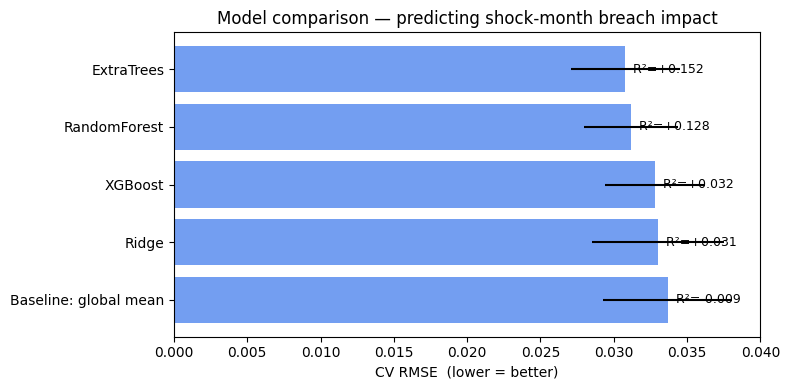

In [9]:
fig, ax = plt.subplots(figsize=(8, 4))
ord_df = results_df.sort_values("rmse_mean")
ax.barh(ord_df["model"], ord_df["rmse_mean"],
        xerr=ord_df["rmse_std"], color="#5b8def", alpha=0.85)
ax.invert_yaxis()
ax.set_xlabel("CV RMSE  (lower = better)")
ax.set_title("Model comparison — predicting shock-month breach impact")
for i, (rmse, r2) in enumerate(zip(ord_df["rmse_mean"], ord_df["r2_mean"])):
    ax.text(rmse, i, f"  R²={r2:+.3f}", va="center", fontsize=9)
plt.tight_layout()
plt.show()


## 7. SHAP interpretation

SHAP turns the XGBoost black box into per-feature evidence for why trusts are resilient — without it, we have predictions but no answer to  actual research question.


Outputs:

- Bar chart of mean |SHAP| — global feature ranking.
- Beeswarm — direction and magnitude per feature.
- Dependence plots for the top 3 features.
- Waterfall plots for the most-resilient and most-fragile predicted shocks.



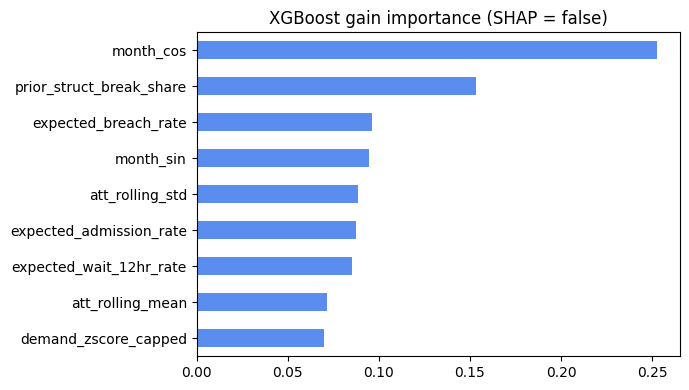

In [18]:
xgb_full = make_xgb()
xgb_full.fit(X, y)

if HAS_SHAP:
    explainer = shap.TreeExplainer(xgb_full)
    shap_values = explainer.shap_values(X)
    shap.summary_plot(shap_values, features=X, feature_names=FEATURES,
                      plot_type="bar", show=True)
    shap.summary_plot(shap_values, features=X, feature_names=FEATURES, show=True)
else:
    # Fallback: gain-based importance
    imp = pd.Series(xgb_full.feature_importances_, index=FEATURES).sort_values()
    imp.plot.barh(figsize=(7, 4), color="#5b8def")
    plt.title("XGBoost gain importance (SHAP = false)")
    plt.tight_layout()
    plt.show()


In [19]:
if HAS_SHAP:
    # Top-3 features by mean |SHAP|, dependence plots
    mean_abs = np.abs(shap_values).mean(axis=0)
    top3 = np.argsort(mean_abs)[-3:][::-1]
    for idx in top3:
        shap.dependence_plot(idx, shap_values, X, feature_names=FEATURES, show=True)


In [20]:
if HAS_SHAP:
    # One resilient (lowest predicted impact) and one fragile (highest) example
    pred = xgb_full.predict(X)
    resilient_idx = int(np.argmin(pred))
    fragile_idx   = int(np.argmax(pred))

    for label, i in [("most resilient predicted", resilient_idx),
                     ("most fragile predicted",   fragile_idx)]:
        row = model_df.iloc[i]
        print(f"\n{label}: {row['provider_name']} ({row['month'].date()})  "
              f"actual breach_impact={row['breach_impact']:+.4f}  "
              f"predicted={pred[i]:+.4f}")
        shap.plots.waterfall(
            shap.Explanation(
                values=shap_values[i],
                base_values=explainer.expected_value,
                data=X[i],
                feature_names=FEATURES,
            ),
            show=True,
        )


## 8. Hypothesis test — variance decomposition

Random-intercept mixed-effects model:

`breach_impact ~ demand_zscore_capped + month_sin + month_cos + (1 | provider_code)`

ICC = between-trust variance / total residual variance. Thresholds: > 0.20 strong, 0.05–0.20 modest, ≈ 0 trusts are interchangeable.

**Result.** ICC = 0.252 → trust-level resilience is real, not noise. Justifies the ranking framework.


In [13]:
if HAS_SM:
    me_df = model_df[["provider_code", TARGET, "demand_zscore_capped",
                      "month_sin", "month_cos"]].copy()
    me = smf.mixedlm(
        f"{TARGET} ~ demand_zscore_capped + month_sin + month_cos",
        data=me_df, groups=me_df["provider_code"],
    ).fit(method="lbfgs")
    print(me.summary())


    var_trust = float(me.cov_re.iloc[0, 0])
    var_resid = float(me.scale)
    icc = var_trust / (var_trust + var_resid)
    print(f"\nVariance(trust intercept) = {var_trust:.6f}")
    print(f"Variance(residual)        = {var_resid:.6f}")
    print(f"ICC                       = {icc:.3f}")
    if icc > 0.2:
        print("=> Strong evidence of trust-level resilience signal.")
    elif icc > 0.05:
        print("=> Modest trust-level signal; most variation is within-trust.")
    else:
        print("=> Trusts barely differ once shock magnitude is accounted for.")
else:
    print("statsmodels not installed; skipping ICC.")


             Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  breach_impact
No. Observations:   914      Method:              REML         
No. Groups:         234      Scale:               0.0008       
Min. group size:    1        Log-Likelihood:      1852.5572    
Max. group size:    12       Converged:           Yes          
Mean group size:    3.9                                        
---------------------------------------------------------------
                     Coef.  Std.Err.   z    P>|z| [0.025 0.975]
---------------------------------------------------------------
Intercept             0.010    0.003  2.871 0.004  0.003  0.017
demand_zscore_capped -0.002    0.001 -1.731 0.083 -0.005  0.000
month_sin             0.004    0.002  2.132 0.033  0.000  0.007
month_cos             0.013    0.002  8.467 0.000  0.010  0.016
Group Var             0.000    0.002                           


Variance(trust intercept) = 0.000267
Variance(resid

## 9. Sensitivity — shock threshold

Default threshold is z ≥ 1.5. Re-rank trusts at z ∈ {1.0, 1.5, 2.0} and check Spearman rank correlation.

**Result.** Pairwise correlations 0.78–0.82 → ranking is robust to the threshold choice.


In [14]:
def trust_mean_impact_at_threshold(z_thresh):
    sub = df[df["demand_zscore"] >= z_thresh].dropna(subset=["breach_impact"])
    return sub.groupby("provider_code")["breach_impact"].mean()

ranks = {f"z>={z}": trust_mean_impact_at_threshold(z).rank() for z in [1.0, 1.5, 2.0]}
rank_df = pd.DataFrame(ranks).dropna()
print(f"Trusts with rankings under all thresholds: {len(rank_df)}")
print("\nSpearman correlation between threshold-based rankings:")
print(rank_df.corr(method="spearman").round(3))


Trusts with rankings under all thresholds: 201

Spearman correlation between threshold-based rankings:
        z>=1.0  z>=1.5  z>=2.0
z>=1.0   1.000   0.782   0.785
z>=1.5   0.782   1.000   0.822
z>=2.0   0.785   0.822   1.000


## 10. Cluster stability — bootstrap ARI

Re-run K-Means (k=4) 30 times with different seeds. Compute pairwise Adjusted Rand Index. Thresholds: > 0.7 stable, 0.4–0.7 partial, < 0.4 noise.

Skipped if `trust_resilience_scores.csv` is not available.


Cluster stability (k=4, 30 seeds): mean ARI = 0.965  median = 0.961  min = 0.913


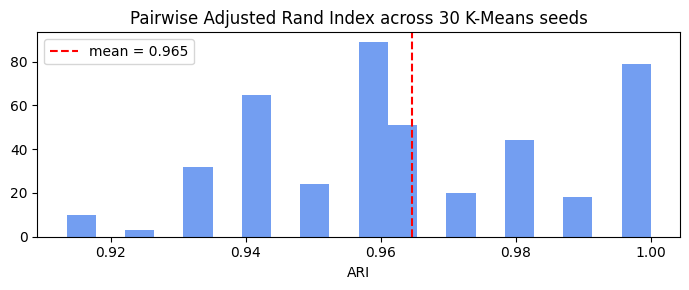

In [15]:
if RESILIENCE_PATH.exists():
    res = pd.read_csv(RESILIENCE_PATH)
    res = res[res["evidence_strength"].isin(["medium", "high"])].copy()
    cluster_features = [
        "breach_resilience_score", "wait_12hr_resilience_score",
        "mean_demand_zscore_capped", "structural_break_share",
        "avg_attendances_during_shock", "n_shocks",
    ]
    res = res.dropna(subset=cluster_features).reset_index(drop=True)
    Xc = StandardScaler().fit_transform(res[cluster_features])

    runs = []
    for seed in range(30):
        runs.append(KMeans(n_clusters=4, random_state=seed, n_init=20).fit_predict(Xc))

    aris = [adjusted_rand_score(runs[i], runs[j])
            for i in range(len(runs)) for j in range(i + 1, len(runs))]
    print(f"Cluster stability (k=4, 30 seeds): "
          f"mean ARI = {np.mean(aris):.3f}  median = {np.median(aris):.3f}  "
          f"min = {np.min(aris):.3f}")
    plt.figure(figsize=(7, 3))
    plt.hist(aris, bins=20, color="#5b8def", alpha=0.85)
    plt.axvline(np.mean(aris), color="red", linestyle="--",
                label=f"mean = {np.mean(aris):.3f}")
    plt.title("Pairwise Adjusted Rand Index across 30 K-Means seeds")
    plt.xlabel("ARI")
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print("trust_resilience_scores.csv not found — skipping cluster stability.")


## 11. Conclusions

- **ICC = 0.25**: differences between trusts are real.
- **Best model R² ≈ 0.15** (ExtraTrees): there is some predictive signal beyond the global mean.
- **Most variation is within trusts**: single shock months are noisy.
- **Rankings are stable** across z-thresholds 1.0, 1.5, and 2.0 (Spearman 0.78–0.82).

**Next steps**

1. Tune XGBoost and LightGBM with nested GroupKFold (Optuna).
2. Add `wait_12hr_impact` as a second target.
3. Test a time split (train ≤ 2018-06, test ≥ 2018-07).
4. Rebuild `expected_*` baselines without shock months in the rolling window.
